In [126]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import os 
from scipy.io import loadmat  ### use this to load .mat files

import os
print(os.getcwd())
print(os.path.exists("data/VORTALL.mat"))

i:\fluid_flow\computational-datadriven-self\notebooks
False


In [127]:
A = loadmat("../data/VORTALL.mat")### load the .mat file
print(A.keys())  ### print the keys of the dictionary to see what is inside
K = A['VORTALL']  ### extract the variable from the dictionary 
print(K.shape)
print(K)  ### print the variable to see what it looks like


dict_keys(['__header__', '__version__', '__globals__', 'VORTALL'])
(89351, 151)
[[-5.92220e-15 -4.68318e-15 -2.94902e-15 ... -9.62025e-15 -8.86421e-15
  -7.27853e-15]
 [-6.01624e-15 -4.61205e-15 -2.58238e-15 ... -9.57891e-15 -8.89550e-15
  -7.31406e-15]
 [-5.92116e-15 -4.68413e-15 -2.50956e-15 ... -9.98390e-15 -8.95430e-15
  -7.50686e-15]
 ...
 [-1.47386e-02 -5.92327e-03 -1.69510e-03 ... -3.54696e-02 -3.64824e-02
  -2.84128e-02]
 [-1.36956e-02 -5.31169e-03 -1.47472e-03 ... -4.07780e-02 -3.80910e-02
  -2.78294e-02]
 [-1.26353e-02 -4.73980e-03 -1.27796e-03 ... -4.49435e-02 -3.89362e-02
  -2.69284e-02]]


In [128]:
frame1 = K[:,0].reshape(199,449, order='F')
print(frame1.shape )



(199, 449)


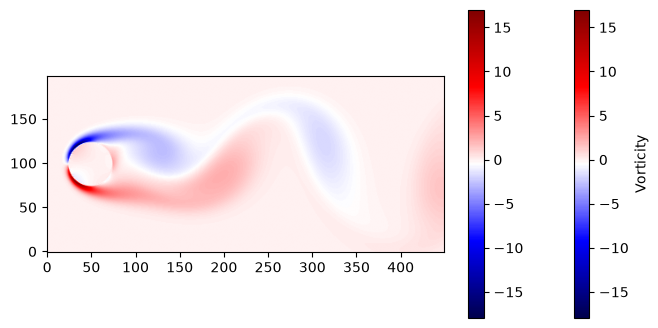

In [129]:
plt.figure(figsize=(8,4))
plt.imshow(frame1, cmap='seismic', origin='lower')
plt.colorbar(label='Vorticity')
plt.colorbar()
plt.show()

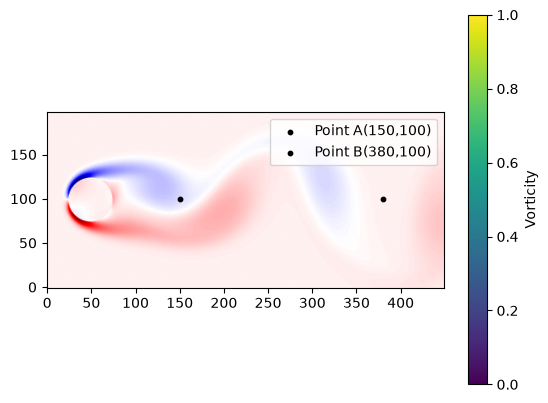

In [130]:
plt.Figure(figsize=(8,4))
plt.imshow(frame1,cmap='seismic', origin='lower')
plt.scatter(150,100,color='Black',s=10,label='Point A(150,100)')
plt.scatter(380,100,color='Black',s=10,label='Point B(380,100)')
plt.legend()
plt.colorbar(label='Vorticity')
plt.show()

In [131]:
K3 =K.reshape(199,449,151,order='F')    # assign all time snapshots 
K3.shape

(199, 449, 151)

In [132]:
ptA=K3[100,150,:]
ptB=K3[100,380,:]
t = np.arange(151)*0.1

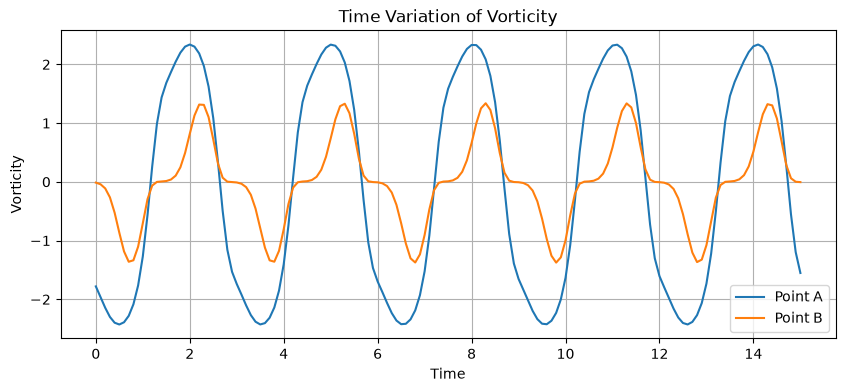

In [133]:
plt.figure(figsize=(10,4))

plt.plot(t,ptA,label='Point A')
plt.plot(t,ptB,label='Point B')

plt.xlabel('Time')
plt.ylabel('Vorticity')
plt.title('Time Variation of Vorticity')
plt.legend()
plt.grid(True)

plt.show()

In [134]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter

fig, ax = plt.subplots(figsize=(8,4))

frame = K[:,0].reshape(199,449,order='F')

im = ax.imshow(frame,
               cmap='seismic',
               origin='lower',
               aspect='auto')

plt.colorbar(im, ax=ax)

def update(i):

    frame = K[:,i].reshape(199,449,order='F')

    im.set_data(frame)

    ax.set_title(f"Time = {i*0.1:.2f} s")

    return [im]

ani = FuncAnimation(fig,
                    update,
                    frames=151,
                    interval=100,
)

writer = FFMpegWriter(fps=10)

ani.save("vorticity1.mp4", writer=writer)

plt.close()

print("Video saved successfully!")

Video saved successfully!


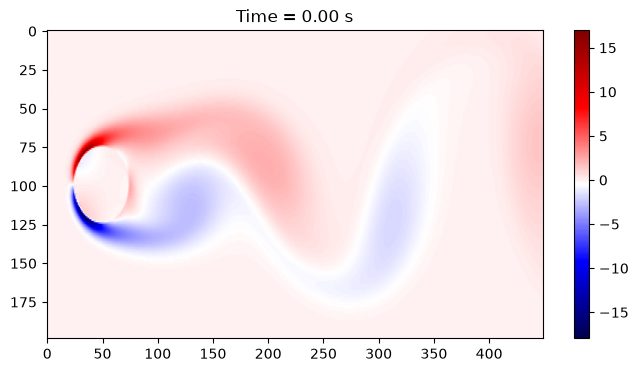

In [135]:
# this is  the K matrix without PCA i.e without taking mean substraction 

fig, ax = plt.subplots(figsize=(8,4))

frame = K[:, 0].reshape(199, 449, order='F')

im = ax.imshow(frame, cmap='seismic', aspect='auto')

plt.colorbar(im, ax=ax)

for i in range(151):

    frame = K[:, i].reshape(199, 449, order='F')

    im.set_data(frame)        # Update only the image
    time = i * 0.1
    ax.set_title("Time = {:.2f} s".format(time))

    plt.pause(0.01)

plt.show()


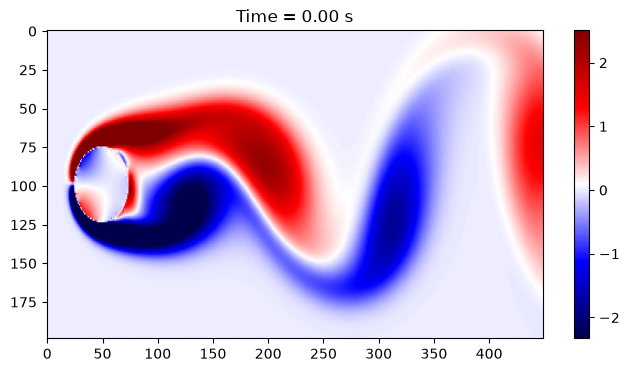

In [136]:
K_mean = np.mean(K, axis=1, keepdims=True)
K_fluct = K - K_mean


# with mean    PCA

fig, ax = plt.subplots(figsize=(8,4))

frame =K_fluct[:, 0].reshape(199, 449, order='F')

im = ax.imshow(frame, cmap='seismic', aspect='auto')

plt.colorbar(im, ax=ax)

for i in range(151):

    frame = K[:, i].reshape(199, 449, order='F')

    im.set_data(frame)        # Update only the image
    time = i * 0.1
    ax.set_title("Time = {:.2f} s".format(time))

    plt.pause(0.01)

plt.show()

In [137]:


fig, ax = plt.subplots(figsize=(8,4))

frame = K_fluct[:,0].reshape(199,449,order='F')

im = ax.imshow(frame,
               cmap='seismic',
               origin='lower',
               aspect='auto')

plt.colorbar(im, ax=ax)

def update(i):

    frame = K_fluct[:,i].reshape(199,449,order='F')

    im.set_data(frame)

    ax.set_title(f"Time = {i*0.1:.2f} s")

    return [im]

ani = FuncAnimation(fig,
                    update,
                    frames=151,
                    interval=100)

writer = FFMpegWriter(fps=10)

ani.save("vorticity2.mp4", writer=writer)

plt.close()

print("Video saved successfully!")

Video saved successfully!


In [138]:
U1 , S1 ,VT1 = np.linalg.svd(K, full_matrices=False)
print(U1)
print(S1)
print(VT1)
print(U1.shape)
print(S1.shape)
print(VT1.shape)

[[-3.50303365e-15  1.66384906e-15  4.45185351e-16 ... -1.21488534e-09
  -1.30080988e-09  3.18474677e-10]
 [-3.91006441e-16 -1.12083047e-15  3.14331462e-15 ...  5.29882064e-11
  -1.08318801e-10 -6.68777446e-11]
 [ 1.43411864e-16  3.15111667e-16 -1.58384919e-16 ...  2.95678795e-11
   2.91260815e-10  2.11805562e-11]
 ...
 [-2.56500761e-04 -5.12704128e-04 -6.26831118e-04 ... -6.67749883e-04
  -9.97601466e-04 -4.08591517e-05]
 [-2.58856999e-04 -4.70096814e-04 -6.53903396e-04 ...  3.40916954e-04
  -6.45282160e-04  7.11504923e-04]
 [-2.60204012e-04 -4.29151823e-04 -6.77424317e-04 ... -2.77910110e-04
   4.22141253e-04  1.77872544e-04]]
[3.57580378e+03 1.29817019e+03 1.27964570e+03 4.66755931e+02
 4.63816628e+02 3.65751031e+02 3.58025504e+02 1.45996593e+02
 1.45112347e+02 7.71372249e+01 7.68813214e+01 3.74530672e+01
 3.73441960e+01 2.18241407e+01 2.17577429e+01 1.24266004e+01
 1.23655073e+01 6.91246851e+00 6.88767488e+00 3.60453697e+00
 3.59081406e+00 1.91946271e+00 1.91508716e+00 9.87731489e-0

In [139]:
U , S ,VT = np.linalg.svd(K_fluct, full_matrices=False)
print(U)
print(S)
print(VT)
print(U.shape)
print(S.shape)
print(VT.shape)

[[ 7.83848903e-16 -1.97367819e-16 -1.33550352e-16 ... -2.52118604e-10
   1.86816037e-10  1.17510735e-01]
 [ 3.68980272e-17 -1.37631437e-16  1.41069793e-16 ...  1.10173493e-10
   2.45923831e-10 -2.24444796e-02]
 [ 7.05621155e-17 -7.95527450e-17 -1.03045926e-16 ... -1.27252027e-10
   6.70635838e-11 -4.69940022e-03]
 ...
 [ 5.12855312e-04 -6.26847821e-04 -3.27189288e-04 ... -9.95279888e-04
   6.18435578e-06 -1.63819013e-04]
 [ 4.70249606e-04 -6.53920334e-04 -4.23245975e-04 ... -6.23998759e-04
   7.08327398e-04  3.72454527e-04]
 [ 4.29305617e-04 -6.77441420e-04 -5.15073934e-04 ...  4.29362511e-04
   1.59412169e-04 -5.78034378e-04]]
[1.29817039e+03 1.27964570e+03 4.66791993e+02 4.63943252e+02
 3.65751035e+02 3.58025504e+02 1.45996978e+02 1.45112813e+02
 7.71372249e+01 7.68813214e+01 3.74531201e+01 3.73441976e+01
 2.18241407e+01 2.17577429e+01 1.24266131e+01 1.23655126e+01
 6.91246851e+00 6.88767488e+00 3.60453710e+00 3.59081509e+00
 1.91946271e+00 1.91508716e+00 9.87731653e-01 9.84806067e-0

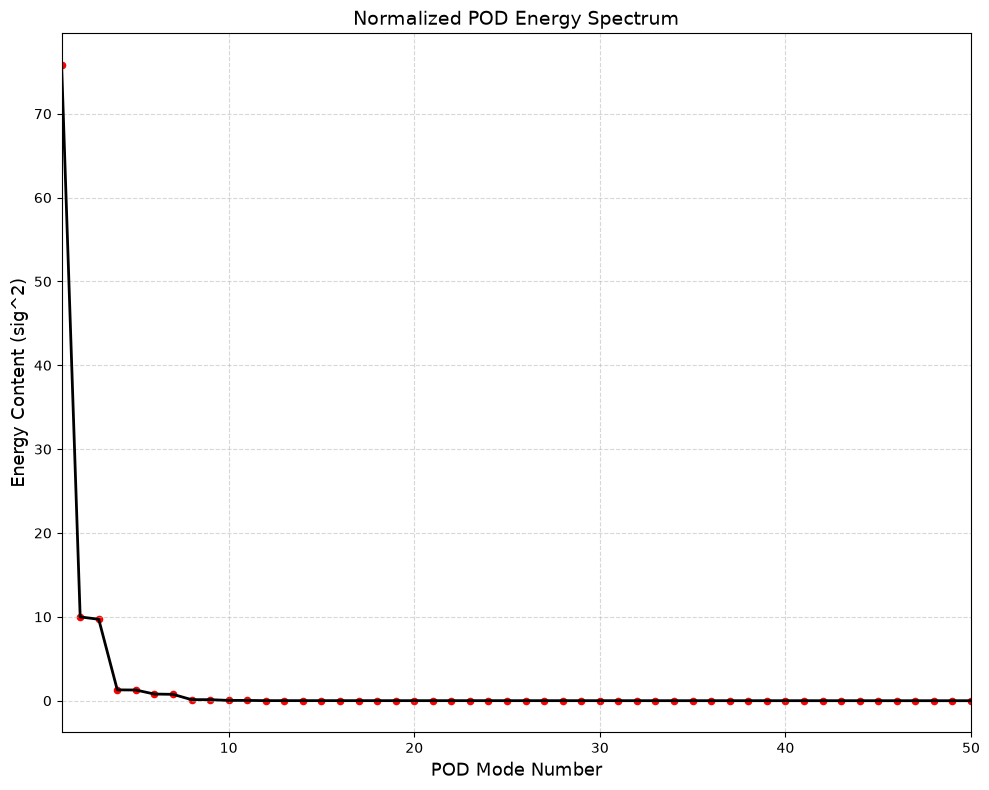

In [140]:
## E is propotional to sigma^2
E = S1**2
E.shape
E_norm = E/np.sum(E) 
mode =np.arange(1,len(S1)+1)


# POD Energy
energy = S1**2
energy = energy / np.sum(energy)

mode = np.arange(1, len(S1)+1)

plt.figure(figsize=(10,8))

plt.plot(mode, energy*100,color='black', linewidth=2)

plt.scatter(mode, energy*100, color='red', s=20)

plt.xlim(1,50)        # Show first 50 modes

plt.xlabel('POD Mode Number', fontsize=13)
plt.ylabel('Energy Content (sig^2)', fontsize=13)
plt.title('Normalized POD Energy Spectrum', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

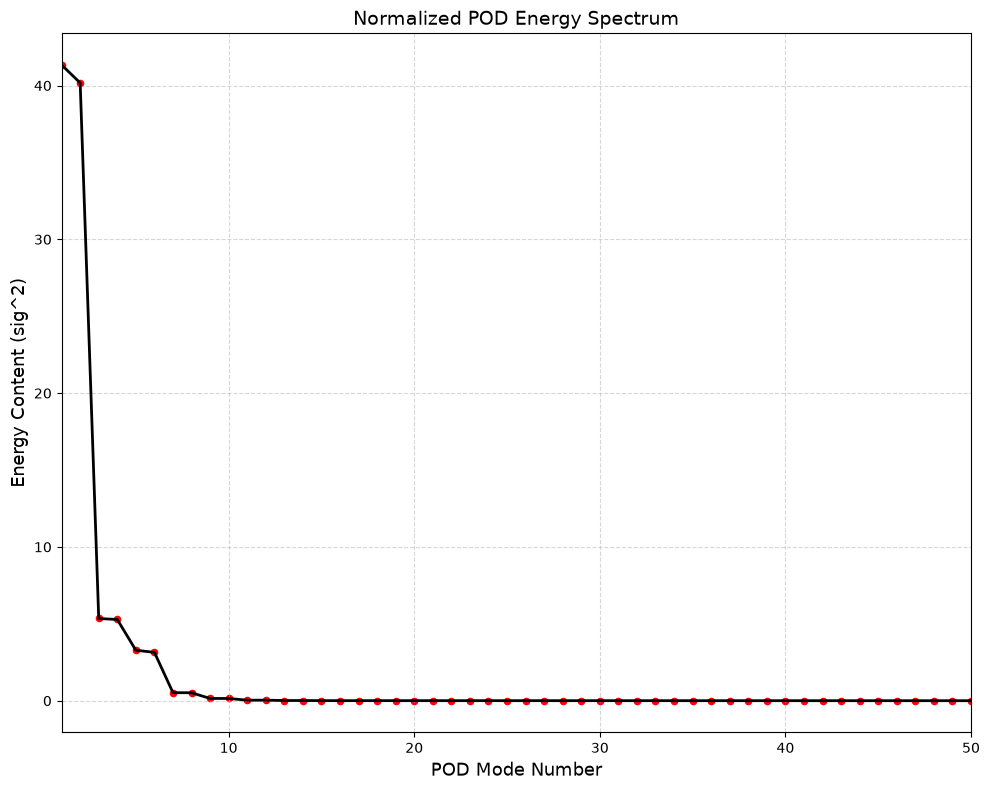

In [141]:
## E is propotional to sigma^2
E = S**2
E.shape
E_norm = E/np.sum(E) 
mode =np.arange(1,len(S+1))


# POD Energy
energy = S**2
energy = energy / np.sum(energy)

mode = np.arange(1, len(S)+1)

plt.figure(figsize=(10,8))

plt.plot(mode, energy*100,color='black', linewidth=2)

plt.scatter(mode, energy*100, color='red', s=20)

plt.xlim(1,50)        # Show first 50 modes

plt.xlabel('POD Mode Number', fontsize=13)
plt.ylabel('Energy Content (sig^2)', fontsize=13)
plt.title('Normalized POD Energy Spectrum', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

(199, 449)


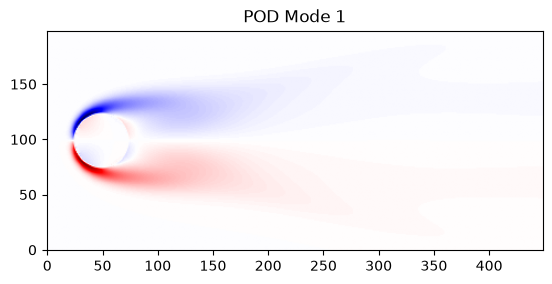

In [142]:
mode1=U1[:,0].reshape(199,449,order='F')
print(mode1.shape)
plt.Figure(figsize=(10,6))
plt.imshow(mode1,cmap='seismic', origin='lower')
plt.title("POD Mode 1")
plt.show()

(199, 449)


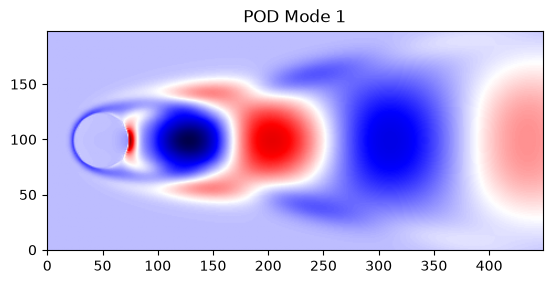

In [143]:
mode1=U[:,0].reshape(199,449,order='F')
print(mode1.shape)
plt.Figure(figsize=(10,6))
plt.imshow(mode1,cmap='seismic', origin='lower')
plt.title("POD Mode 1")
plt.show()

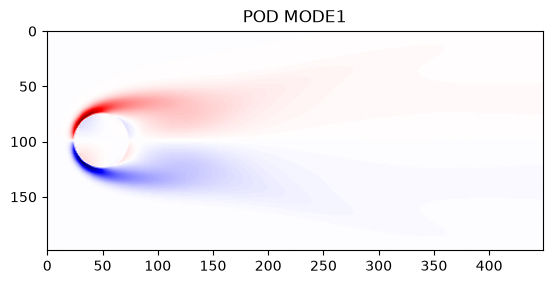

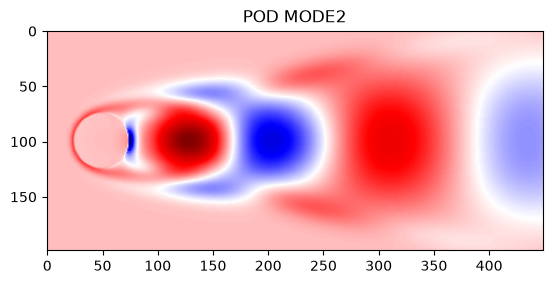

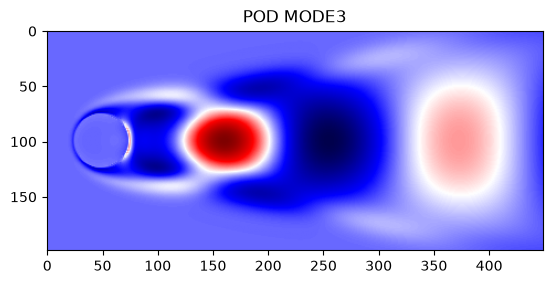

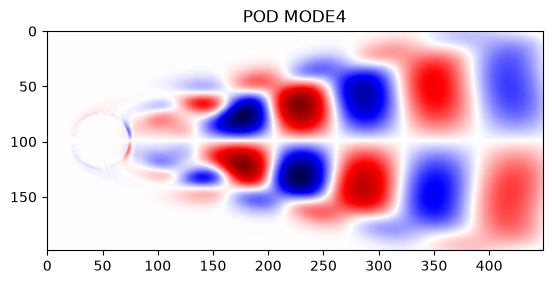

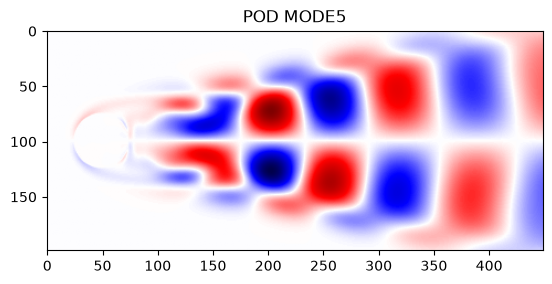

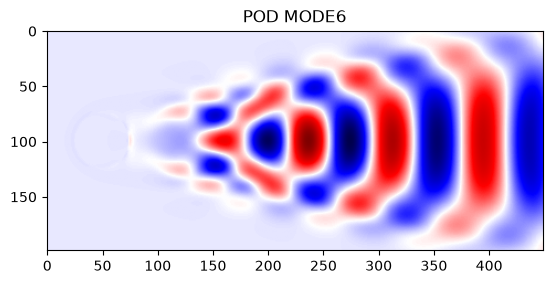

In [144]:


for i in range(6):
    mode =U1[:,i].reshape(199,449,order='F')
    plt.Figure(figsize=(10,8))
    plt.imshow(mode,cmap='seismic')
    plt.colorbar
    plt.title(f'POD MODE{i+1}')
    plt.show()

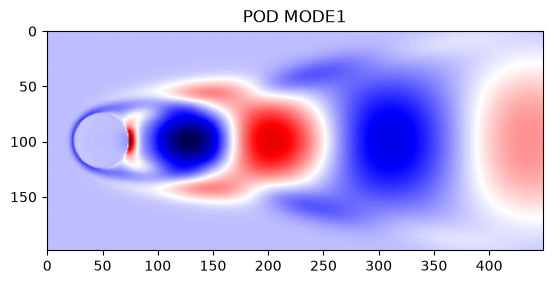

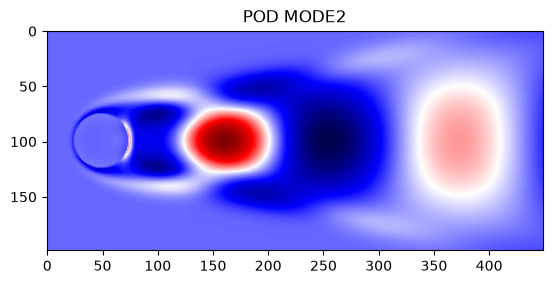

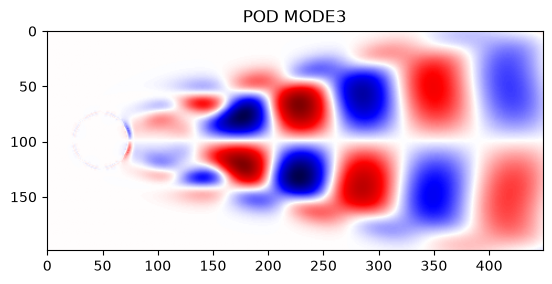

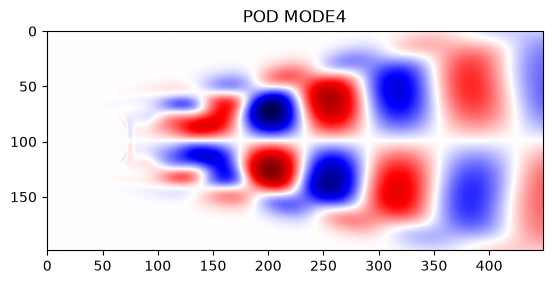

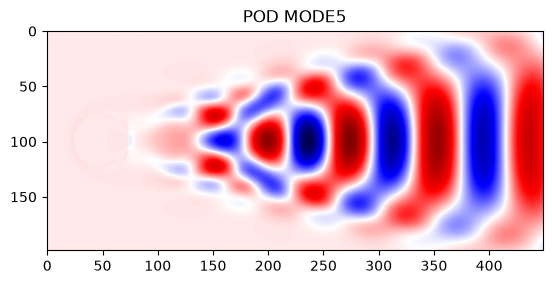

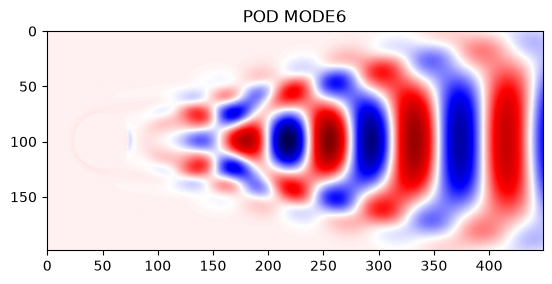

In [145]:


for i in range(6):
    mode =U[:,i].reshape(199,449,order='F')
    plt.Figure(figsize=(10,8))
    plt.imshow(mode,cmap='seismic')
    plt.colorbar
    plt.title(f'POD MODE{i+1}')
    plt.show()

In [146]:

r = 9
u_r1 =U1[:,:r]
s_r1 =np.diag(S1[:r])
vt_r1 = VT1[:r,:]
K_rec1 = u_r1 @ s_r1 @ vt_r1
print(u_r1.shape)
print(s_r1.shape)
print(vt_r1.shape)
print(K_rec1.shape)

(89351, 9)
(9, 9)
(9, 151)
(89351, 151)


In [147]:
r = 9
u_r =U[:,:r]
s_r =np.diag(S[:r])
vt_r = VT[:r,:]
K_rec = u_r @ s_r @ vt_r
print(u_r.shape)
print(s_r.shape)
print(vt_r.shape)
print(K_rec.shape)



(89351, 9)
(9, 9)
(9, 151)
(89351, 151)


Text(0.5, 1.0, 'Reconstructed r Modes)')

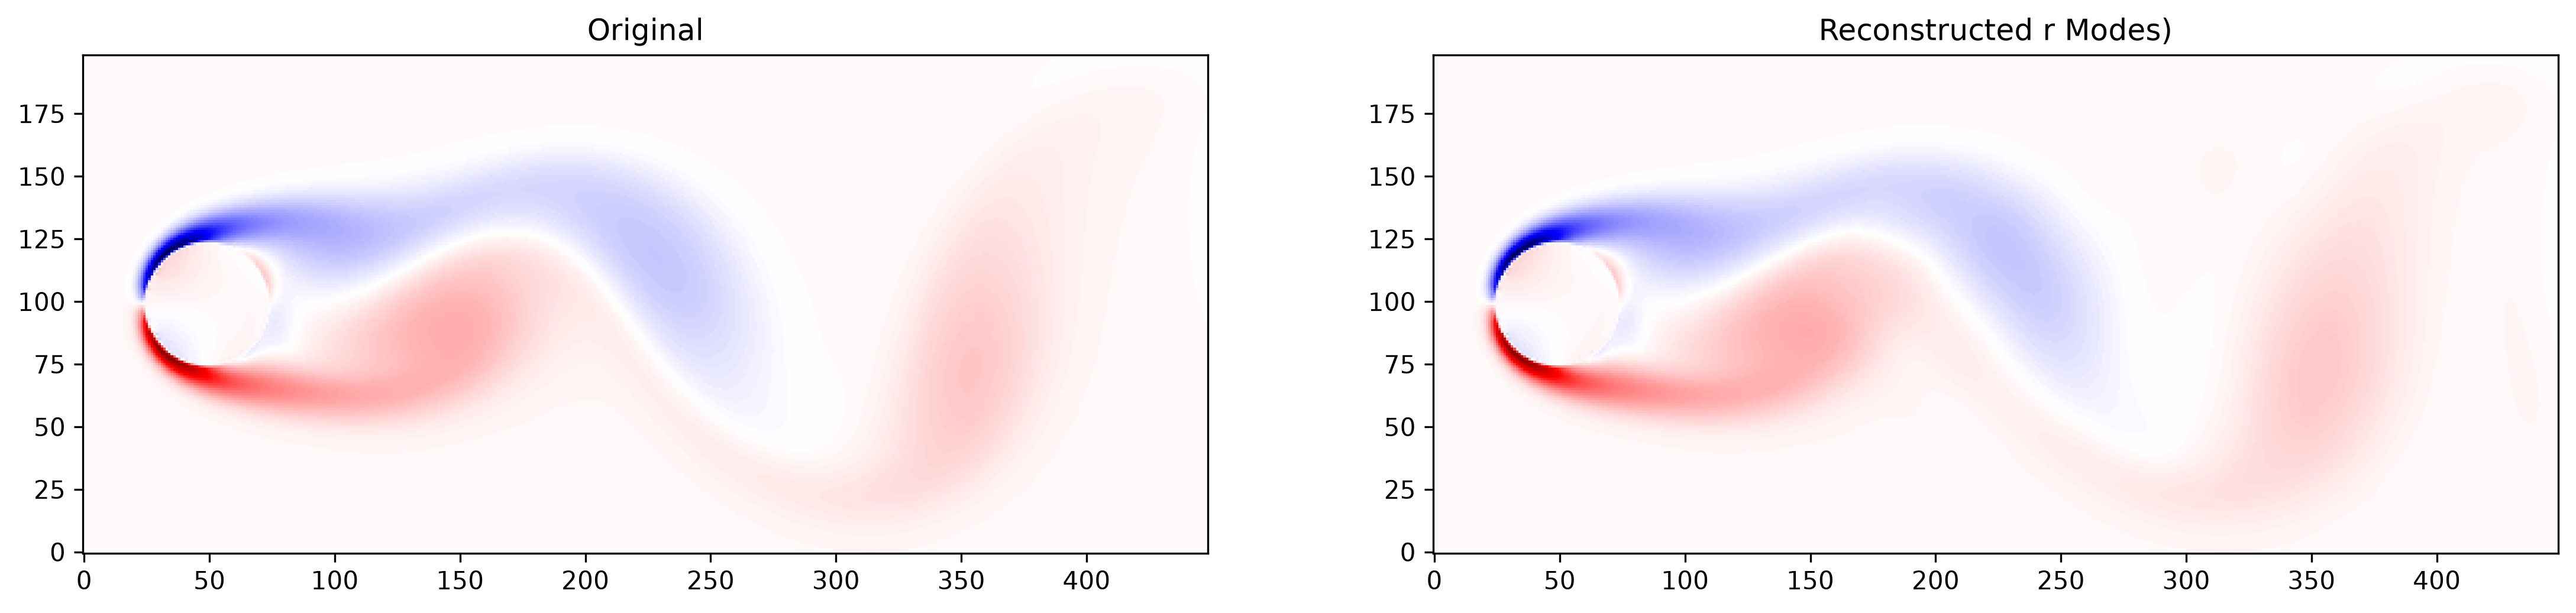

In [148]:
snapshot = 50

original1 = K[:, snapshot].reshape(199, 449, order='F')   # taking cloumn wise snapshots here 50
reconstructed1 = K_rec1[:, snapshot].reshape(199, 449, order='F')
ig, ax = plt.subplots(1, 2,figsize=(18, 5), dpi=300)


# Original
im1 = ax[0].imshow(original1, cmap='seismic', origin='lower')
ax[0].set_title('Original')

# Reconstructed
im2 = ax[1].imshow(reconstructed1,cmap='seismic',origin='lower')
ax[1].set_title('Reconstructed r Modes)')


In [149]:
snapshot = 50

original = K_fluct[:, snapshot].reshape(199, 449, order='F')   # taking cloumn wise snapshots here 50
reconstructed = K_rec[:, snapshot].reshape(199, 449, order='F')


Text(0.5, 1.0, 'Reconstructed r Modes)')

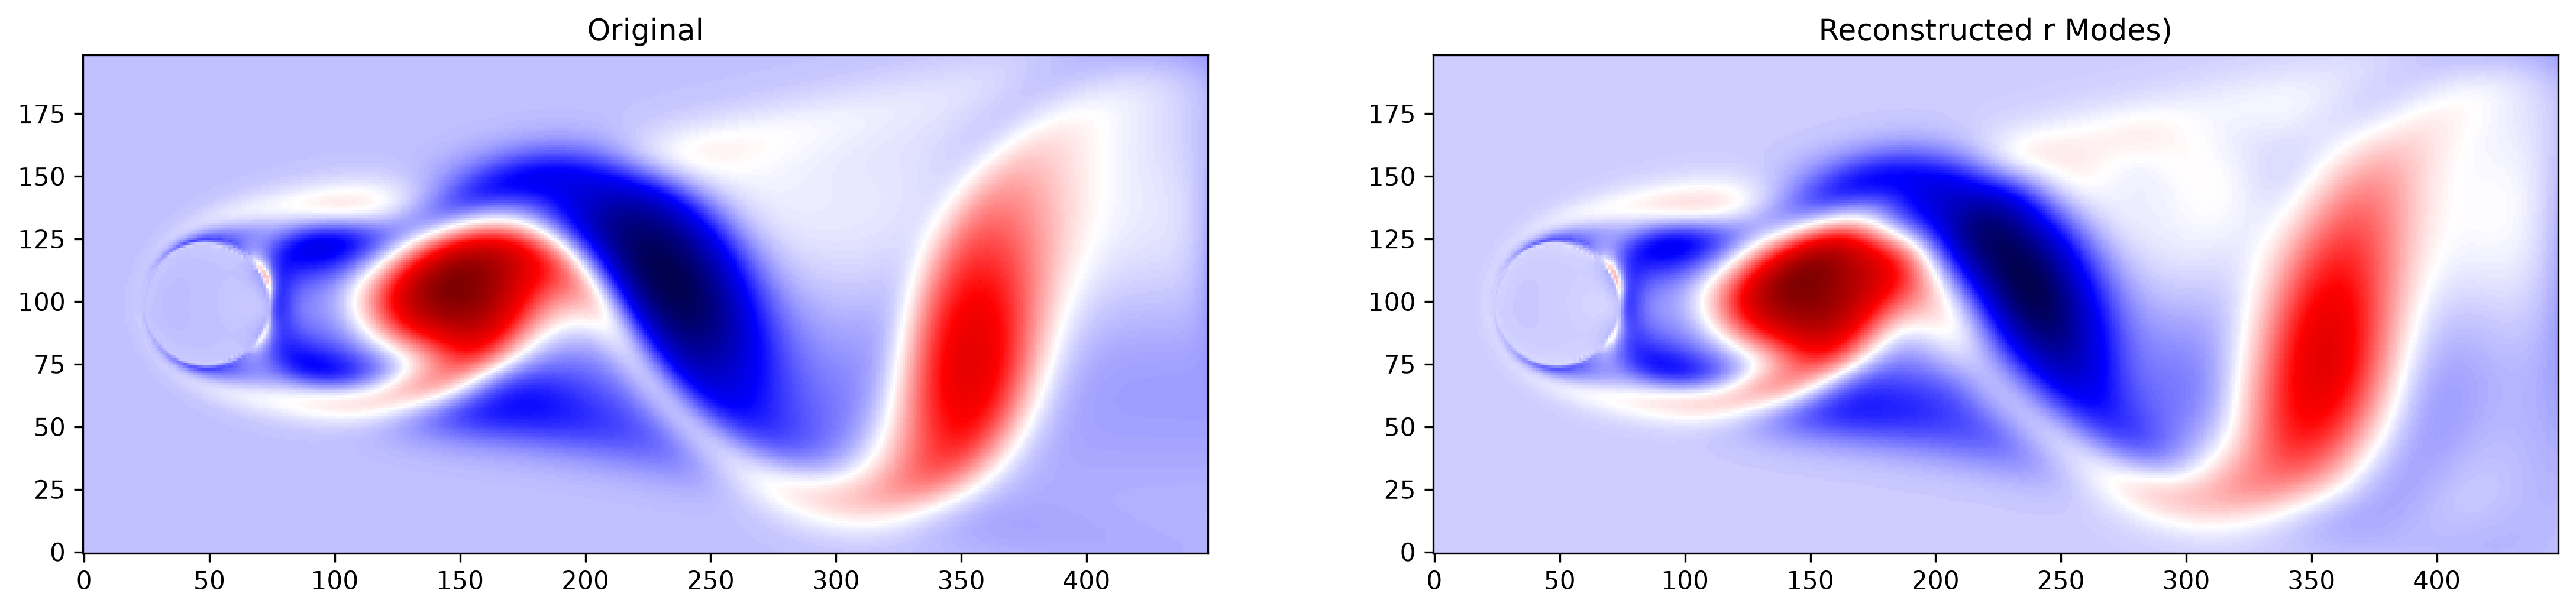

In [150]:
fig, ax = plt.subplots(1, 2,figsize=(18, 5), dpi=300)


# Original
im1 = ax[0].imshow(original, cmap='seismic', origin='lower')
ax[0].set_title('Original')

# Reconstructed
im2 = ax[1].imshow(reconstructed,cmap='seismic',origin='lower')
ax[1].set_title('Reconstructed r Modes)')


Text(0.5, 1.0, 'Reconstructed r Modes)')

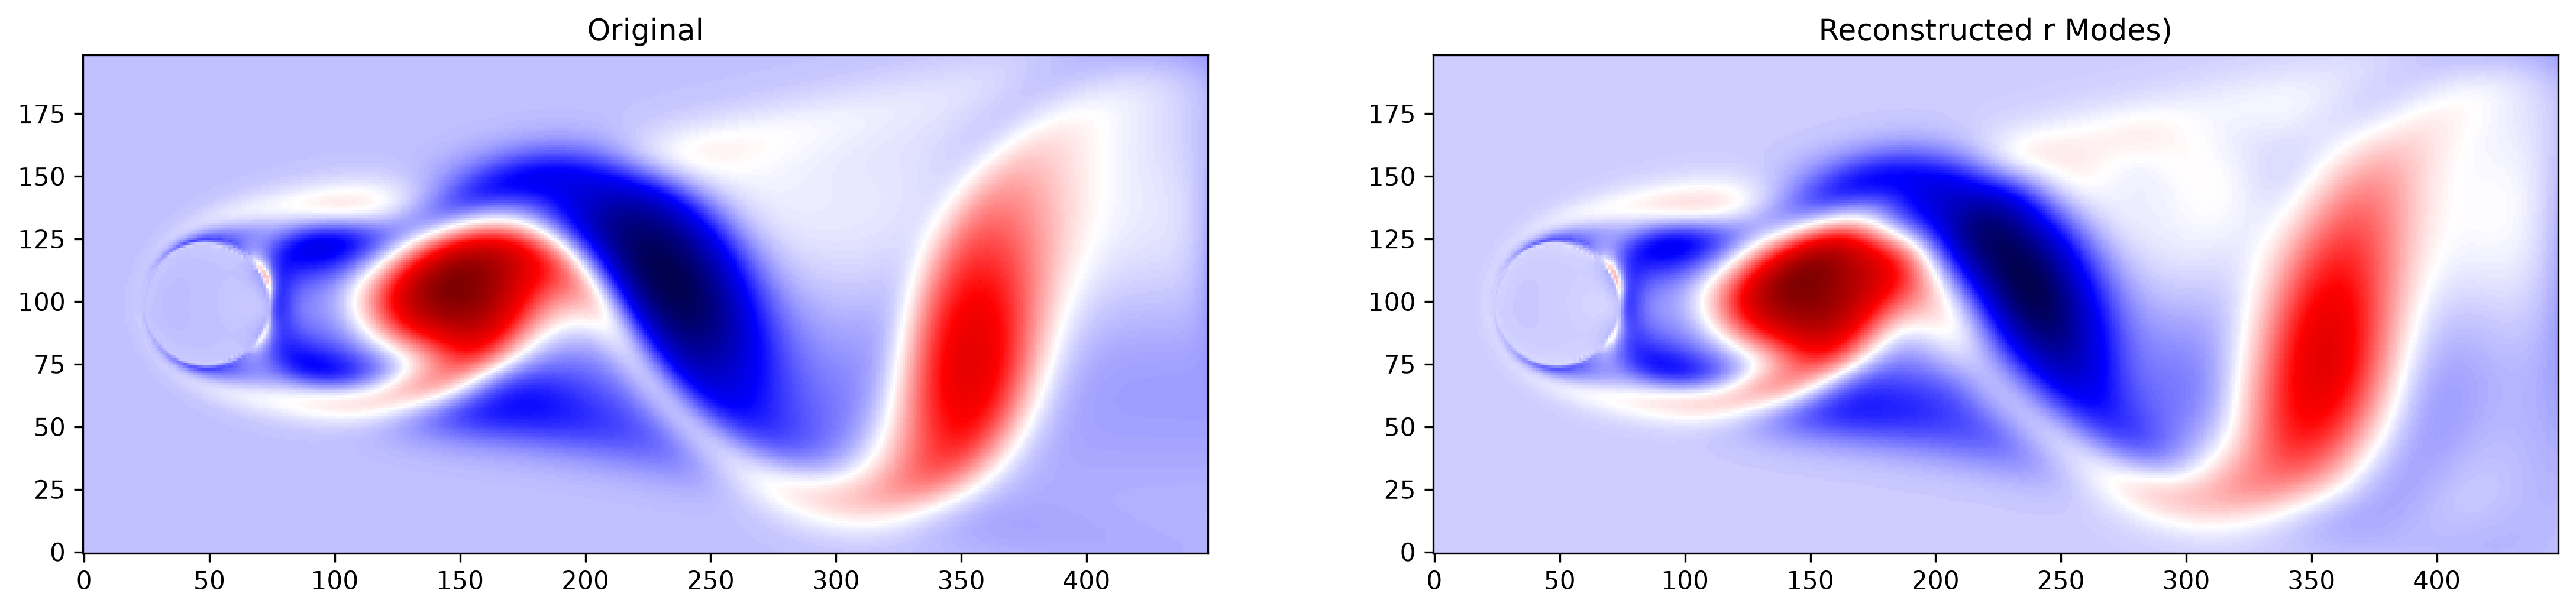

In [151]:
fig, ax = plt.subplots(1, 2,figsize=(18, 5), dpi=300)


# Original
im1 = ax[0].imshow(original, cmap='seismic', origin='lower')
ax[0].set_title('Original')

# Reconstructed
im2 = ax[1].imshow(reconstructed,cmap='seismic',origin='lower')
ax[1].set_title('Reconstructed r Modes)')


In [152]:
error = np.linalg.norm(K- K_rec1, 'fro') / np.linalg.norm(K, 'fro')   #using foribinus norm im short magnitude of all elemnts from mat 

print("Relative Reconstruction Error =", error)

Relative Reconstruction Error = 0.030847972867965066


In [153]:
error = np.linalg.norm(K_fluct- K_rec, 'fro') / np.linalg.norm(K, 'fro')   #using foribinus norm im short magnitude of all elemnts from mat 

print("Relative Reconstruction Error =", error)

Relative Reconstruction Error = 0.024469045705341922


In [154]:
fig, ax = plt.subplots(1, 2, figsize=(18,5))

frame1 = K_fluct[:,0].reshape(199,449,order='F')
frame2 = K_rec[:,0].reshape(199,449,order='F')

im1 = ax[0].imshow(frame1,cmap='seismic', origin='lower', aspect='auto',)
im2 = ax[1].imshow(frame2,cmap='seismic', origin='lower', aspect='auto',)

ax[0].set_title("Original (Fluctuating)")
ax[1].set_title("Reconstructed")

plt.colorbar(im1,ax=ax[0],shrink =0.8)
plt.colorbar(im2,ax=ax[1],shrink =0.8)

def update(i):
     frame1 = K_fluct[:,i].reshape(199,449,order='F')
     frame2 = K_rec[:,i].reshape(199,449,order='F')
     im1.set_data(frame1)
     im2.set_data(frame2)
     ax[0].set_title(f"Original   Time = {i*0.1:.2f} s")
     ax[1].set_title(f"Reconstructed   Time = {i*0.1:.2f} s")
     return im1, im2

ani = FuncAnimation(fig,update,frames=151,interval=100, blit=True)
writer = FFMpegWriter(fps=10)

ani.save("Originalpca _vs_Reconstructed.mp4",
         writer=writer,
         dpi=200)

plt.close()

print("Video saved successfully!")


Video saved successfully!


In [155]:
fig, ax = plt.subplots(1, 2, figsize=(18,5))

frame1 = K[:,0].reshape(199,449,order='F')
frame2 = K_rec1[:,0].reshape(199,449,order='F')

im1 = ax[0].imshow(frame1,cmap='seismic', origin='lower', aspect='auto',)
im2 = ax[1].imshow(frame2,cmap='seismic', origin='lower', aspect='auto',)

ax[0].set_title("Original ")
ax[1].set_title("Reconstructed")

plt.colorbar(im1,ax=ax[0],shrink =0.8)
plt.colorbar(im2,ax=ax[1],shrink =0.8)

def update(i):
     frame1 = K[:,i].reshape(199,449,order='F')
     frame2 = K_rec1[:,i].reshape(199,449,order='F')
     im1.set_data(frame1)
     im2.set_data(frame2)
     ax[0].set_title(f"Original   Time = {i*0.1:.2f} s")
     ax[1].set_title(f"Reconstructed   Time = {i*0.1:.2f} s")
     return im1, im2

ani = FuncAnimation(fig,update,frames=151,interval=100, blit=True)
writer = FFMpegWriter(fps=10)

ani.save("Originalnonpca_vs_Reconstructed2.mp4",
         writer=writer,
         dpi=200)

plt.close()

print("Video saved successfully!")


Video saved successfully!


In [156]:
A = s_r1 @ vt_r1

print(A.shape)

(9, 151)


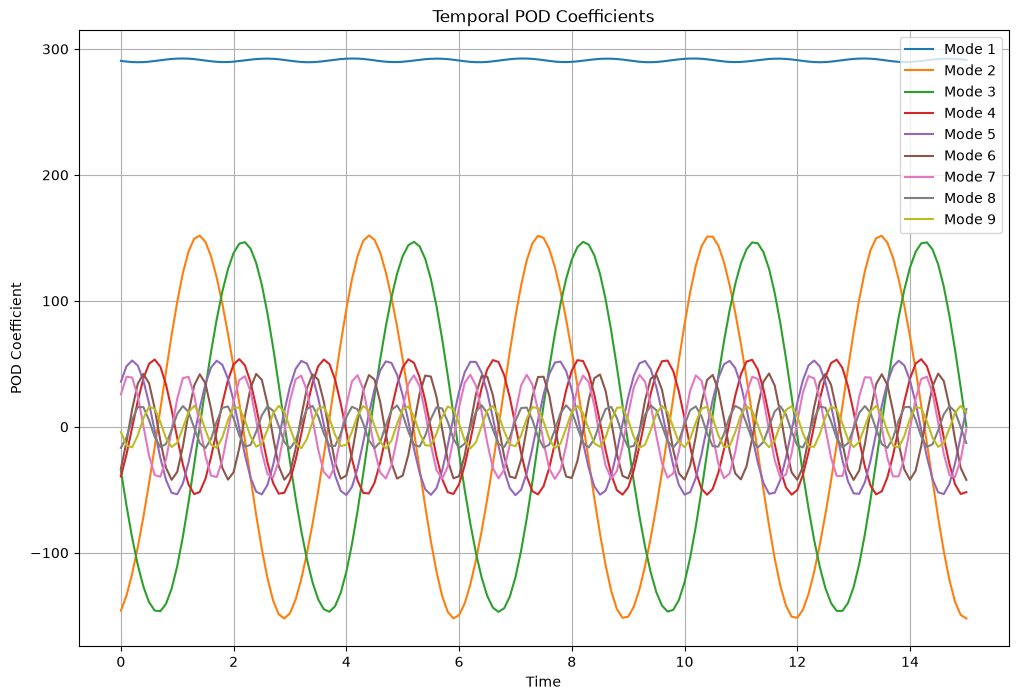

In [157]:
import matplotlib.pyplot as plt
import numpy as np

dt = 0.1  # Your VORTALL dataset uses dt = 0.1

t = np.arange(A.shape[1]) * dt

plt.figure(figsize=(12, 8))

for i in range(9):
    plt.plot(t, A[i], label=f'Mode {i+1}')

plt.xlabel("Time")
plt.ylabel("POD Coefficient")
plt.title("Temporal POD Coefficients")
plt.legend()
plt.grid(True)
plt.show()

In [158]:
A_dynamic = A[1:, :]
print("A_dynamic.shape:", A_dynamic.shape)

A_dynamic.shape: (8, 151)


In [159]:
dt = 0.1

A_dot = np.gradient(A_dynamic, dt, axis=1)

In [160]:
X = A_dynamic.T
X_dot = A_dot.T

print(X.shape)
print(X_dot.shape)

(151, 8)
(151, 8)


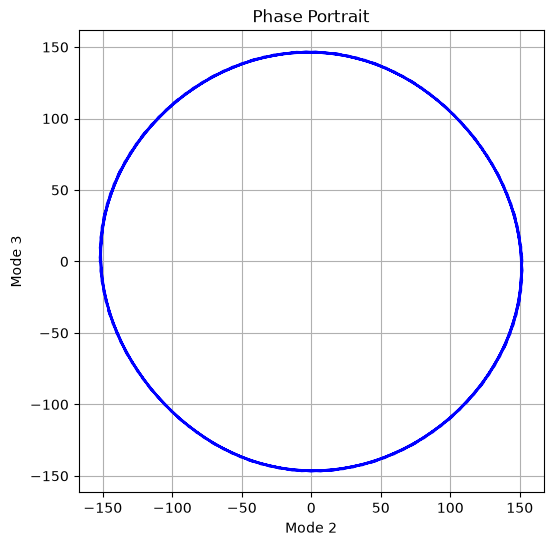

In [161]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.plot(A_dynamic[0], A_dynamic[1], 'b')
plt.xlabel("Mode 2")
plt.ylabel("Mode 3")
plt.title("Phase Portrait")
plt.grid(True)
plt.show()

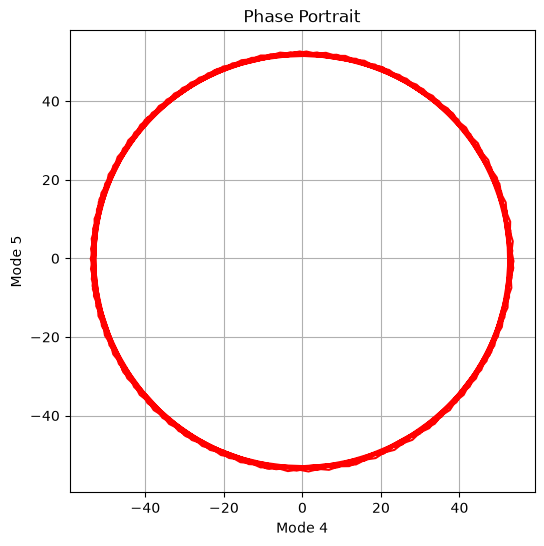

In [162]:
plt.figure(figsize=(6,6))
plt.plot(A_dynamic[2], A_dynamic[3], 'r')
plt.xlabel("Mode 4")
plt.ylabel("Mode 5")
plt.title("Phase Portrait")
plt.grid(True)
plt.show()

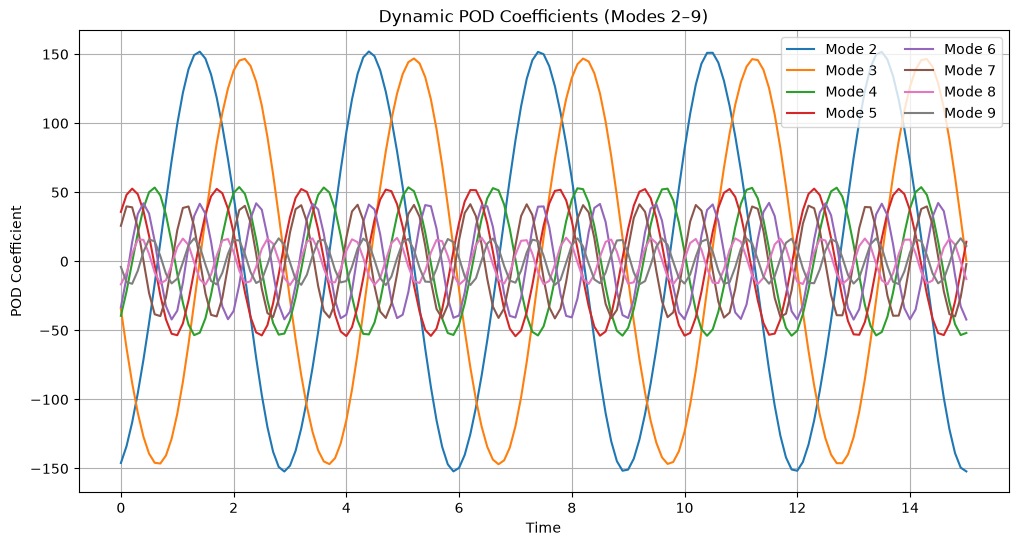

In [163]:
plt.figure(figsize=(12,6))

for i in range(1, 9):   # Modes 2 to 9
    plt.plot(t, A[i], label=f"Mode {i+1}")

plt.xlabel("Time")
plt.ylabel("POD Coefficient")
plt.title("Dynamic POD Coefficients (Modes 2–9)")
plt.legend(ncol=2)
plt.grid(True)
plt.show()

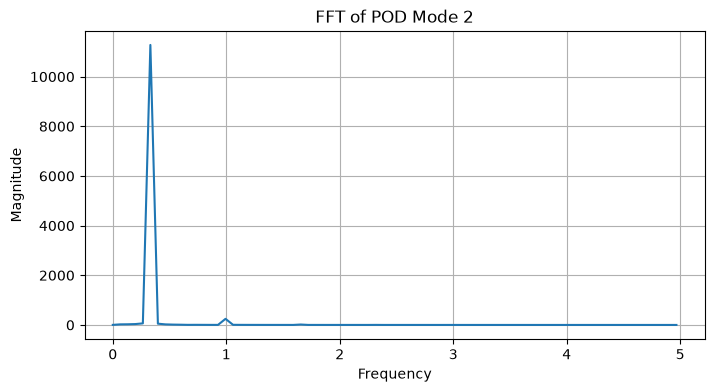

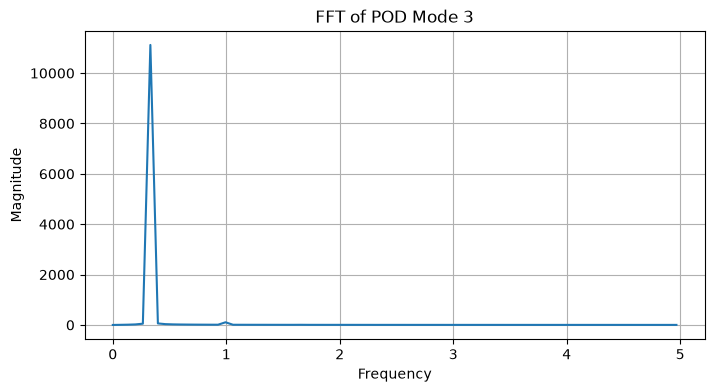

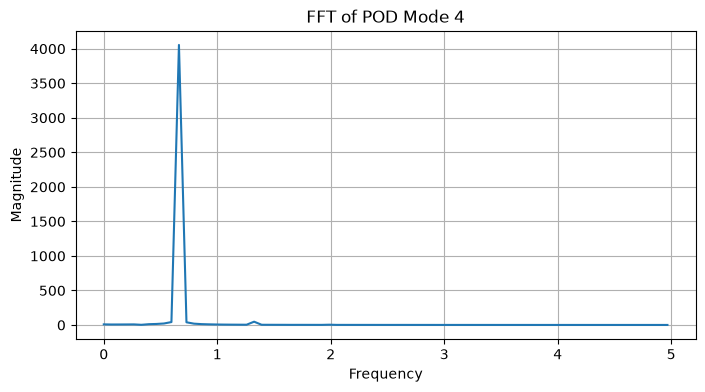

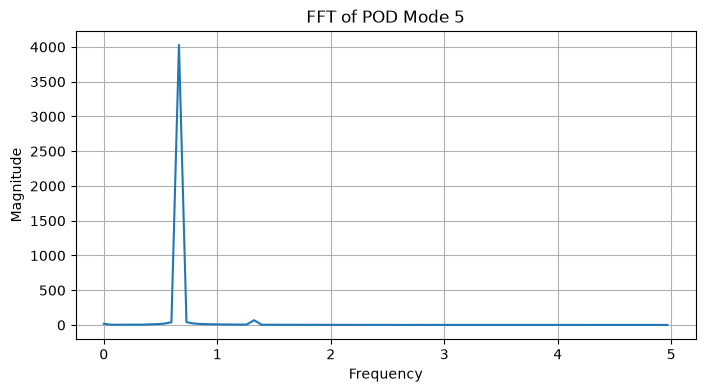

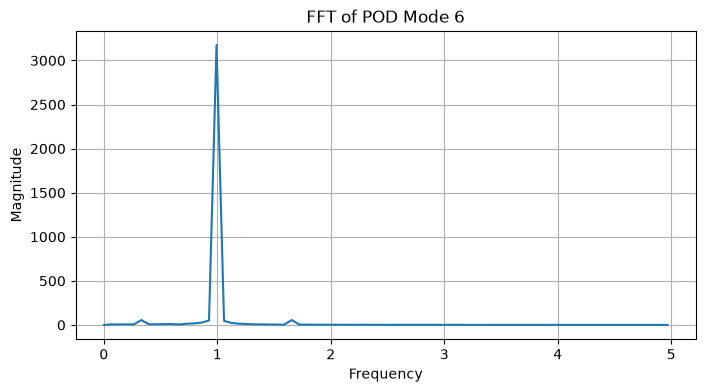

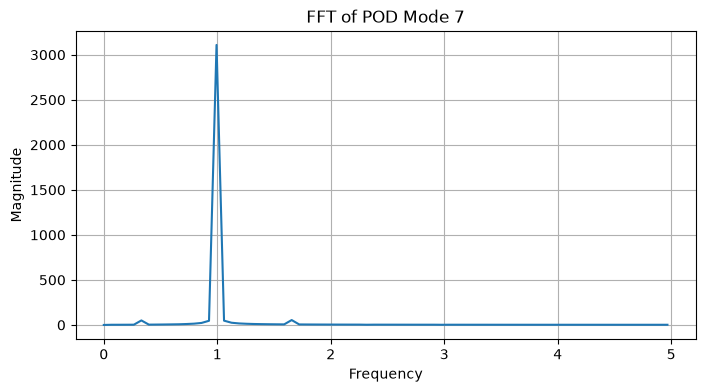

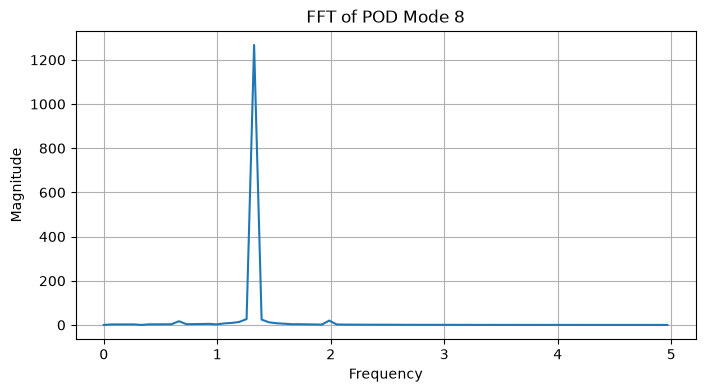

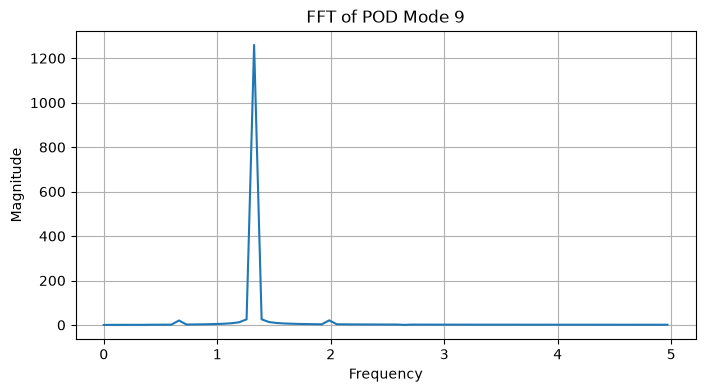

In [164]:
import numpy as np
import matplotlib.pyplot as plt

dt = 0.1

for i in range(A_dynamic.shape[0]):

    signal = A_dynamic[i]

    freq = np.fft.rfftfreq(len(signal), dt)
    fft = np.abs(np.fft.rfft(signal))

    plt.figure(figsize=(8,4))
    plt.plot(freq, fft)
    plt.title(f"FFT of POD Mode {i+2}")
    plt.xlabel("Frequency")
    plt.ylabel("Magnitude")
    plt.grid(True)
    plt.show()

In [165]:
A_dot = np.gradient(A_dynamic, dt, axis=1)

print(A_dot.shape)

(8, 151)


In [166]:
X = A_dynamic.T
X_dot = A_dot.T

print(X.shape)
print(X_dot.shape)

(151, 8)
(151, 8)


In [167]:
mean = X.mean(axis=0)
std = X.std(axis=0)

X_norm = (X - mean) / std
Xdot_norm = X_dot / std

In [168]:
from itertools import combinations_with_replacement

def build_library(X):

    n_samples, n_features = X.shape

    Theta = [np.ones((n_samples,1))]
    names = ["1"]

    # Linear
    for i in range(n_features):
        Theta.append(X[:,i:i+1])
        names.append(f"x{i+1}")

    # Quadratic
    for i,j in combinations_with_replacement(range(n_features),2):
        Theta.append((X[:,i]*X[:,j]).reshape(-1,1))
        names.append(f"x{i+1}x{j+1}")

    Theta = np.hstack(Theta)

    return Theta,names

In [169]:
Theta,names = build_library(X_norm)

print(Theta.shape)

(151, 45)


In [170]:
def STLSQ(Theta,Xdot,lam=0.05,n_iter=10):

    Xi=np.linalg.lstsq(Theta,Xdot,rcond=None)[0]

    for _ in range(n_iter):

        small=np.abs(Xi)<lam
        Xi[small]=0

        for k in range(Xdot.shape[1]):

            big=~small[:,k]

            if np.sum(big)==0:
                continue

            Xi[big,k]=np.linalg.lstsq(
                Theta[:,big],
                Xdot[:,k],
                rcond=None
            )[0]

    return Xi

In [171]:
Xi = STLSQ(
    Theta,
    Xdot_norm,
    lam=0.05,
    n_iter=10
)

In [172]:
for eq in range(Xi.shape[1]):

    print("\n"+"="*60)
    print(f"Equation {eq+1}")

    for coef,name in zip(Xi[:,eq],names):

        if abs(coef)>1e-8:
            print(f"{coef:10.5f} * {name}")


Equation 1
-117289.92410 * 1
 166.61060 * x1
123374.26360 * x2
54271.09374 * x3
51490.51679 * x4
30492.88583 * x5
23722.75448 * x6
-9974.77914 * x7
12149.16015 * x8
75642.64503 * x1x1
-195069.31569 * x1x2
-6036.34795 * x1x3
-32884.49206 * x1x4
3788.04619 * x1x5
-58179.15206 * x1x6
6640.23020 * x1x7
-14182.44936 * x1x8
46262.10416 * x2x2
-42339.06934 * x2x3
30748.52942 * x2x4
-80364.91160 * x2x5
-16758.66617 * x2x6
12666.31529 * x2x7
 -32.22889 * x2x8
-7420.41088 * x3x3
-20431.47783 * x3x4
17826.44443 * x3x5
-38108.78589 * x3x6
-13031.40812 * x3x7
-12868.69432 * x3x8
18694.85198 * x4x4
42776.95896 * x4x5
23438.03997 * x4x6
-12894.17039 * x4x7
11189.13597 * x4x8
-10138.54272 * x5x5
-225.03970 * x5x6
1050.47688 * x5x7
 399.43777 * x5x8
-10614.63437 * x6x6
 481.97867 * x6x7
-1174.75401 * x6x8
2474.20534 * x7x7
  42.52964 * x7x8
2389.61655 * x8x8

Equation 2
-13874.68149 * 1
1088.37279 * x1
26479.46071 * x2
12431.99029 * x3
3815.50529 * x4
6530.00851 * x5
9168.20155 * x6
-2985.63221 * x7
1